Etape 1: Definition du Churn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_transaction = pd.read_csv("transaction_clean.csv")

In [2]:
import pandas as pd

df_transaction['invoice_date'] = pd.to_datetime(df_transaction['invoice_date'])

df_unique_orders = df_transaction[['customer_id', 'invoice_id', 'invoice_date']].drop_duplicates()

df_unique_orders = df_unique_orders[df_unique_orders.groupby('customer_id')['invoice_id'].transform('count') >= 2]

df_unique_orders = df_unique_orders.sort_values(by=['customer_id', 'invoice_date'])

df_unique_orders['delay'] = df_unique_orders.groupby('customer_id')['invoice_date'].diff()

df_final_delays = df_unique_orders['delay'].dropna()

delai_moyen = df_final_delays.mean()
delai_median = df_final_delays.median()

print(f"Délai moyen : {delai_moyen}")
print(f"Délai médian : {delai_median}")

Délai moyen : 56 days 10:20:34.214339497
Délai médian : 27 days 00:00:00


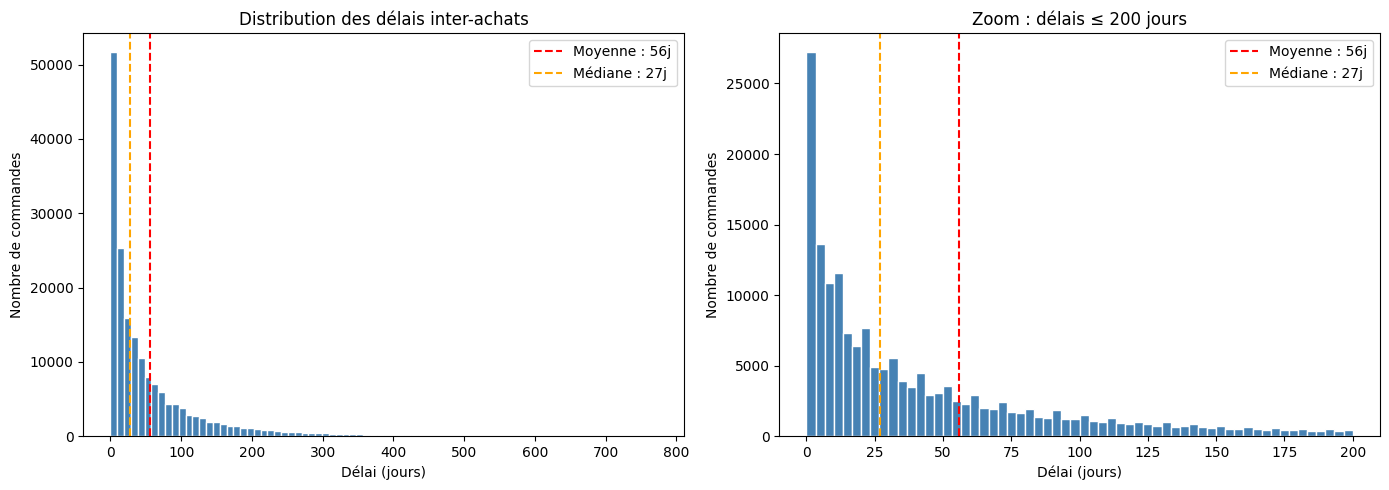

% de délais > 90j  : 19.8%
% de délais > 180j : 7.3%
% de délais > 365j : 1.1%


In [3]:

# Distribution des délais inter-achats (en jours)
delays_days = df_final_delays.dt.days

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(delays_days, bins=80, color='steelblue', edgecolor='white')
axes[0].axvline(delai_moyen.days, color='red', linestyle='--', label=f'Moyenne : {delai_moyen.days}j')
axes[0].axvline(delai_median.days, color='orange', linestyle='--', label=f'Médiane : {delai_median.days}j')
axes[0].set_title('Distribution des délais inter-achats')
axes[0].set_xlabel('Délai (jours)')
axes[0].set_ylabel('Nombre de commandes')
axes[0].legend()

# Zoom sur les 200 premiers jours pour voir la masse principale
axes[1].hist(delays_days[delays_days <= 200], bins=60, color='steelblue', edgecolor='white')
axes[1].axvline(delai_moyen.days, color='red', linestyle='--', label=f'Moyenne : {delai_moyen.days}j')
axes[1].axvline(delai_median.days, color='orange', linestyle='--', label=f'Médiane : {delai_median.days}j')
axes[1].set_title('Zoom : délais ≤ 200 jours')
axes[1].set_xlabel('Délai (jours)')
axes[1].set_ylabel('Nombre de commandes')
axes[1].legend()

plt.tight_layout()
plt.show()

# La queue droite est bien visible : certains clients ont des délais > 300j (très saisonniers)
print(f"% de délais > 90j  : {(delays_days > 90).mean()*100:.1f}%")
print(f"% de délais > 180j : {(delays_days > 180).mean()*100:.1f}%")
print(f"% de délais > 365j : {(delays_days > 365).mean()*100:.1f}%")


In [4]:

# Percentiles pour choisir un seuil de churn objectif
print("Percentiles des délais inter-achats :")
for p in [50, 75, 90, 95, 99]:
    print(f"  P{p} : {int(np.percentile(delays_days, p))} jours")

# Choix du seuil : on retient le P90
# - La médiane (~27j) et la moyenne (~56j) montrent une forte asymétrie
# - Le P75 correspond encore à la fréquence normale des clients réguliers
# - Au-delà du P90, on entre clairement dans la queue droite :
#   clients occasionnels ou très saisonniers
# - Un client sans achat depuis 90j a très probablement rompu son cycle habituel
SEUIL_CHURN = int(np.percentile(delays_days, 90))
print(f"\nSeuil de churn retenu : {SEUIL_CHURN} jours (P90)")


Percentiles des délais inter-achats :
  P50 : 27 jours
  P75 : 72 jours
  P90 : 151 jours
  P95 : 218 jours
  P99 : 371 jours

Seuil de churn retenu : 151 jours (P90)


In [5]:

# Labellisation des clients : churné ou non
# Date de référence = dernière date observée dans le dataset
date_ref = df_transaction['invoice_date'].max()

# Recency : nombre de jours depuis la dernière commande de chaque client
last_order = df_transaction.groupby('customer_id')['invoice_date'].max()
recency = (date_ref - last_order).dt.days

# churn = 1 si inactif depuis plus du seuil, 0 sinon
churn = (recency > SEUIL_CHURN).astype(int)

df_churn = pd.DataFrame({'recency_days': recency, 'churn': churn})

print(f"Date de référence : {date_ref.date()}")
print(f"Seuil de churn    : {SEUIL_CHURN} jours\n")
print(f"Clients churné  (churn=1) : {churn.sum()} ({churn.mean()*100:.1f}%)")
print(f"Clients actifs  (churn=0) : {(churn == 0).sum()} ({(churn == 0).mean()*100:.1f}%)")
print()
print(df_churn.head(10))


Date de référence : 2011-12-09
Seuil de churn    : 151 jours

Clients churné  (churn=1) : 31190 (63.5%)
Clients actifs  (churn=0) : 17956 (36.5%)

             recency_days  churn
customer_id                     
12346.0               325      1
12347.0                 1      0
12348.0                74      0
12349.0                18      0
12350.0               309      1
12351.0               374      1
12352.0                35      0
12353.0               203      1
12354.0               231      1
12355.0               213      1
